# SafeSathi — Motion Event Classifier: Training Notebook

**Goal:** train a classifier that looks at a short window of accelerometer +
gyroscope summary statistics from a phone and predicts one of five events:

`normal`, `running`, `phone_snatch`, `violent_movement`, `sudden_fall`

This is the exact model the AI microservice loads at startup
(`app/core/settings.py` → `motion_classifier_path`) to score incoming
sensor windows from the mobile app in real time.

## Why synthetic training data

No labeled real-world dataset of phone-snatch / violent-movement /
sudden-fall accelerometer recordings exists to train on honestly —
collecting one safely (i.e. actually staging assaults) is its own
research project, well outside this project's scope.

Instead, each class is generated from a **documented, physically-reasoned
distribution** — grounded in how each event actually moves a phone, not
arbitrary numbers picked to make the model look good. The reasoning for
every class is written out just before its parameters below, so the
model's behaviour can be traced back to a stated assumption rather than
treated as a black box.

This notebook is a **bootstrap**: the moment a real, labeled dataset
exists, the training step below is a drop-in replacement — same feature
contract, same output path — nothing downstream needs to change.


In [1]:
import json
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, train_test_split

sns.set_theme(style="whitegrid")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 1. Configuration

Feature order and class labels are fixed and must match what the FastAPI
service sends at inference time (`app/services/motion_classifier_service.py`)
— this list is the contract between training and serving.


In [2]:
SAMPLES_PER_CLASS = 600

FEATURE_NAMES = [
    "accel_mean",
    "accel_peak",
    "accel_variance",
    "accel_peak_to_mean",
    "gyro_mean",
    "gyro_peak",
    "gyro_variance",
    "gyro_peak_to_mean",
]

CLASS_LABELS = ["normal", "running", "phone_snatch", "violent_movement", "sudden_fall"]


## 2. Per-class distributions — and the reasoning behind each

Units: accelerometer magnitude in **m/s²**, gyroscope magnitude in **rad/s**
(matching `SensorLog.model.ts` on the backend and what the mobile app's
`useMotionDetector` hook actually converts and sends — see that hook's
`G_TO_MS2` conversion constant).

| Class | Reasoning |
|---|---|
| `normal` | Near-gravity magnitude (~9.8 m/s²), low variance, low gyro — a phone at rest or being carried steadily. |
| `running` | Elevated mean + periodic variance from footstrike; moderate gyro from natural arm swing. |
| `phone_snatch` | A short, very sharp acceleration **and** rotation spike — high peak, high gyro peak (the twist as it's grabbed) — but the *mean* isn't pulled down, since there's no free-fall phase. |
| `violent_movement` (struggling) | Sustained high variance and moderately high peak on both sensors — not one clean spike like a snatch, closer to continuous chaotic motion. |
| `sudden_fall` | Very high peak (the impact) but a **lower** mean than the sustained-high classes, because part of the window is a near-free-fall dip (magnitude near 0) before impact. That peak-high / mean-low combination is the distinguishing fall signature — not peak alone. |

Each profile below is a `(mean, std)` pair per feature, sampled from a
(clipped-to-non-negative) normal distribution.


In [3]:
@dataclass
class ClassProfile:
    accel_mean: tuple
    accel_peak: tuple
    accel_variance: tuple
    gyro_mean: tuple
    gyro_peak: tuple
    gyro_variance: tuple


CLASS_PROFILES = {
    "normal": ClassProfile(
        accel_mean=(9.8, 0.6), accel_peak=(11.5, 1.2), accel_variance=(0.8, 0.4),
        gyro_mean=(0.15, 0.08), gyro_peak=(0.4, 0.15), gyro_variance=(0.05, 0.03),
    ),
    "running": ClassProfile(
        accel_mean=(13.0, 1.5), accel_peak=(18.0, 2.5), accel_variance=(3.0, 1.0),
        gyro_mean=(0.5, 0.15), gyro_peak=(1.0, 0.3), gyro_variance=(0.25, 0.1),
    ),
    "phone_snatch": ClassProfile(
        accel_mean=(12.0, 2.0), accel_peak=(32.0, 5.0), accel_variance=(6.0, 2.0),
        gyro_mean=(1.2, 0.4), gyro_peak=(6.5, 1.5), gyro_variance=(2.5, 0.8),
    ),
    "violent_movement": ClassProfile(
        accel_mean=(14.0, 2.5), accel_peak=(24.0, 4.0), accel_variance=(7.0, 2.0),
        gyro_mean=(1.8, 0.5), gyro_peak=(3.5, 1.0), gyro_variance=(1.8, 0.6),
    ),
    "sudden_fall": ClassProfile(
        accel_mean=(6.5, 1.8), accel_peak=(28.0, 5.0), accel_variance=(8.0, 2.5),
        gyro_mean=(0.8, 0.3), gyro_peak=(2.5, 0.8), gyro_variance=(1.0, 0.4),
    ),
}


## 3. Generate the dataset

In [4]:
def _sample_positive(rng, mean_std):
    mean, std = mean_std
    return float(max(0.0, rng.normal(mean, std)))


def generate_dataset(samples_per_class: int, seed: int):
    rng = np.random.default_rng(seed)
    rows, labels = [], []

    for label in CLASS_LABELS:
        profile = CLASS_PROFILES[label]
        for _ in range(samples_per_class):
            accel_mean = _sample_positive(rng, profile.accel_mean)
            accel_peak = max(accel_mean, _sample_positive(rng, profile.accel_peak))
            accel_variance = _sample_positive(rng, profile.accel_variance)
            gyro_mean = _sample_positive(rng, profile.gyro_mean)
            gyro_peak = max(gyro_mean, _sample_positive(rng, profile.gyro_peak))
            gyro_variance = _sample_positive(rng, profile.gyro_variance)

            rows.append([
                accel_mean, accel_peak, accel_variance,
                accel_peak / accel_mean if accel_mean > 0 else 0.0,
                gyro_mean, gyro_peak, gyro_variance,
                gyro_peak / gyro_mean if gyro_mean > 0 else 0.0,
            ])
            labels.append(label)

    return np.array(rows), np.array(labels)


X, y = generate_dataset(SAMPLES_PER_CLASS, RANDOM_SEED)
df = pd.DataFrame(X, columns=FEATURE_NAMES)
df["label"] = y
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (3000, 9)


,accel_mean,accel_peak,accel_variance,accel_peak_to_mean,gyro_mean,gyro_peak,gyro_variance,gyro_peak_to_mean,label
0,9.982830,10.252019,1.100180,1.026965,0.225245,0.225245,0.010935,1.000000,normal
1,9.876704,11.120509,0.793280,1.125933,0.081756,0.531910,0.073334,6.506024,normal
2,9.839618,12.852689,0.987004,1.306218,0.081257,0.455313,0.021234,5.603392,normal
3,10.327070,11.440089,0.726055,1.107777,0.095526,0.583381,0.045364,6.107064,normal
4,9.543003,11.077440,1.012924,1.160792,0.179236,0.461910,0.062925,2.577111,normal


### Quick EDA — do the classes actually look separable?

In [5]:
df.groupby("label")[FEATURE_NAMES].mean().loc[CLASS_LABELS]


,accel_mean,accel_peak,accel_variance,accel_peak_to_mean,gyro_mean,gyro_peak,gyro_variance,gyro_peak_to_mean
label,,,,,,,,
normal,9.777123,11.533609,0.789217,1.183412,0.153517,0.408249,0.049779,3.919820
running,13.093344,17.972785,2.995618,1.386931,0.503634,1.015235,0.250362,2.327318
phone_snatch,11.985132,31.868237,5.808691,2.745857,1.197454,6.505143,2.467379,6.417753
violent_movement,13.808762,24.025578,6.844875,1.800546,1.822413,3.564656,1.792466,2.288366
sudden_fall,6.572901,28.611583,8.128296,4.765581,0.814940,2.483440,1.000161,4.045043


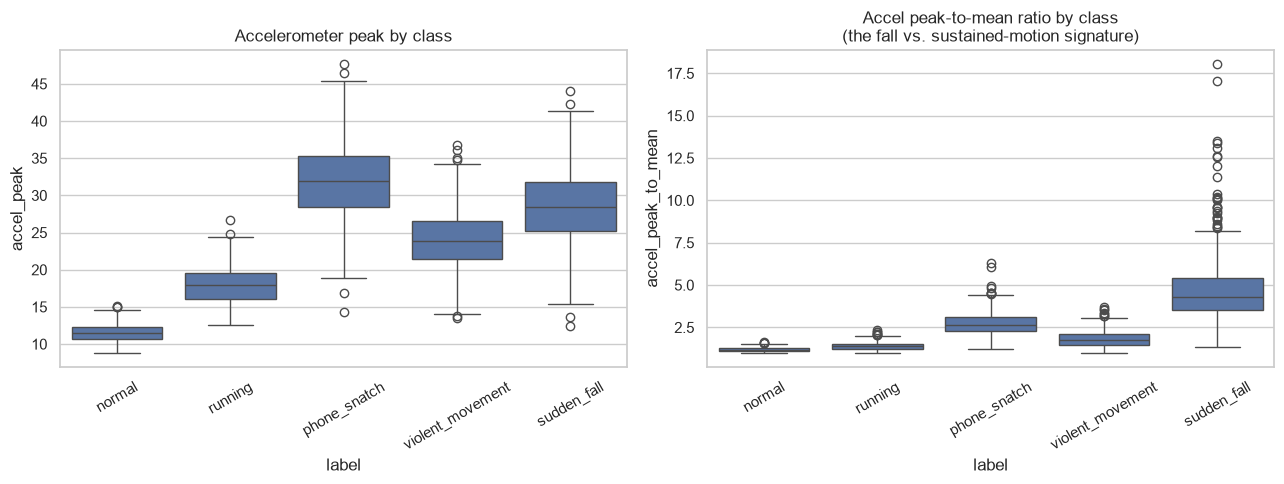

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="label", y="accel_peak", order=CLASS_LABELS, ax=axes[0])
axes[0].set_title("Accelerometer peak by class")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="label", y="accel_peak_to_mean", order=CLASS_LABELS, ax=axes[1])
axes[1].set_title("Accel peak-to-mean ratio by class\n(the fall vs. sustained-motion signature)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


`sudden_fall` should visibly separate from `phone_snatch` / `violent_movement`
here even though all three have high peaks — the peak-to-mean ratio is what
tells them apart, matching the reasoning in the table above.

## 4. Train / test split


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"Train: {X_train.shape[0]} samples · Test: {X_test.shape[0]} samples")


Train: 2400 samples · Test: 600 samples


## 5. Train the model

A `RandomForestClassifier` — chosen for two practical reasons, not just
default habit: it handles the non-linear peak/mean interactions each class
profile above relies on, and its `feature_importances_` gives a directly
inspectable explanation of *why* it makes a given call (important for a
safety-critical classifier you may have to justify in a viva).


In [8]:
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    class_weight="balanced",
)
clf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

## 6. Evaluate

In [9]:
y_pred = clf.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)
print(classification_report(y_test, y_pred))


                  precision    recall  f1-score   support

          normal       1.00      1.00      1.00       120
    phone_snatch       0.97      0.95      0.96       120
         running       1.00      0.98      0.99       120
     sudden_fall       0.97      0.98      0.98       120
violent_movement       0.94      0.97      0.95       120

        accuracy                           0.98       600
       macro avg       0.98      0.98      0.98       600
    weighted avg       0.98      0.98      0.98       600



In [10]:
cv_scores = cross_val_score(clf, X, y, cv=5)
print(f"5-fold CV accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")


5-fold CV accuracy: 0.9753 +/- 0.0051


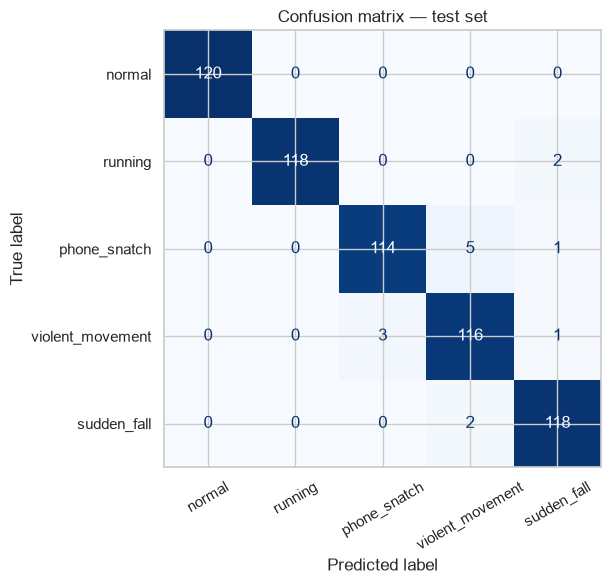

In [11]:
cm = confusion_matrix(y_test, y_pred, labels=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(6.5, 6))
ConfusionMatrixDisplay(cm, display_labels=CLASS_LABELS).plot(ax=ax, cmap="Blues", colorbar=False)
plt.xticks(rotation=30)
plt.title("Confusion matrix — test set")
plt.tight_layout()
plt.show()


Watch specifically for confusion between `phone_snatch` and
`violent_movement` — they're the two deliberately-similar classes (both
sharp, both high-gyro), so some overlap there is expected and honest,
not a sign of a broken model. Confusion involving `sudden_fall` should be
much rarer, since its low-mean signature is fairly distinct.


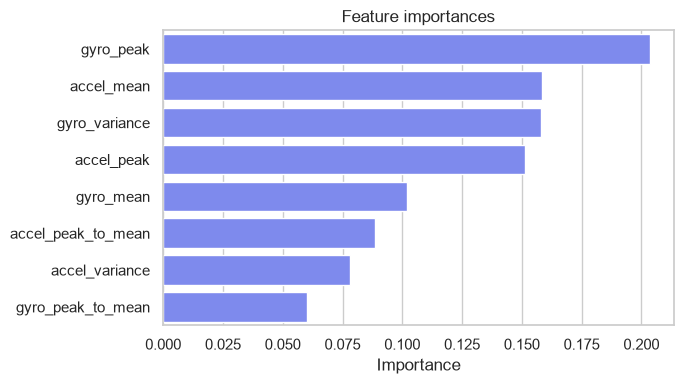

  gyro_peak: 0.2035
  accel_mean: 0.1586
  gyro_variance: 0.1579
  accel_peak: 0.1513
  gyro_mean: 0.1019
  accel_peak_to_mean: 0.0887
  accel_variance: 0.0780
  gyro_peak_to_mean: 0.0601


In [12]:
importances = sorted(zip(FEATURE_NAMES, clf.feature_importances_), key=lambda p: -p[1])

fig, ax = plt.subplots(figsize=(7, 4))
names, values = zip(*importances)
sns.barplot(x=list(values), y=list(names), ax=ax, color="#6C7BFF")
ax.set_title("Feature importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

for name, importance in importances:
    print(f"  {name}: {importance:.4f}")


`accel_peak_to_mean` and `accel_mean` dominating matches the design intent
directly — that ratio is exactly what separates a fall's "spike after a
low patch" from sustained violent shaking, as reasoned in section 2.

## 7. Save the model — this is the file the running service actually loads

`app/core/settings.py` points `motion_classifier_path` at this exact file.
Saving here (not somewhere else, then copying manually) means re-running
this notebook top-to-bottom *is* the retraining workflow — no separate
export step to forget.


In [13]:
import joblib

# Resolve relative to the ai-services/ project root, regardless of
# where Jupyter's working directory happens to be.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "app").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

artifacts_dir = PROJECT_ROOT / "app" / "ml_artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

model_path = artifacts_dir / "motion_classifier.joblib"
joblib.dump(clf, model_path)

metadata = {
    "feature_names": FEATURE_NAMES,
    "class_labels": CLASS_LABELS,
    "trained_on": "synthetic data — see section 2 of this notebook for the reasoning",
    "samples_per_class": SAMPLES_PER_CLASS,
    "test_accuracy": report["accuracy"],
    "cv_accuracy_mean": float(cv_scores.mean()),
    "cv_accuracy_std": float(cv_scores.std()),
    "per_class_f1": {label: report[label]["f1-score"] for label in CLASS_LABELS},
}
metadata_path = artifacts_dir / "motion_classifier_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2))

print(f"Saved model to    {model_path}")
print(f"Saved metadata to {metadata_path}")


Saved model to    C:\Users\Administrator\Desktop\Roni-Creations\Final Year Project\SafeSathi\ai-services\app\ml_artifacts\motion_classifier.joblib
Saved metadata to C:\Users\Administrator\Desktop\Roni-Creations\Final Year Project\SafeSathi\ai-services\app\ml_artifacts\motion_classifier_metadata.json


## 8. How this connects to the rest of SafeSathi

- The FastAPI AI microservice loads `app/ml_artifacts/motion_classifier.joblib`
  at startup (see `app/core/settings.py` → `motion_classifier_path`) and
  uses it to score every sensor window the mobile app uploads.
- `app/ml_artifacts/` is **committed to git** (unlike the large Vosk speech
  models, which are gitignored and downloaded separately) — so after
  re-running this notebook, `git add app/ml_artifacts && git commit && git push`
  is the entire deployment step. Render redeploys automatically and picks
  up the new model.
- To verify a deploy actually picked up a fresh model, check
  `GET /health` on the AI microservice — `motion_classifier_loaded: true`
  confirms the file loaded without error, though it can't tell you *which*
  version loaded, so check the commit that triggered the deploy if that
  matters.
- `scripts/train_motion_classifier.py` (the plain-script version this
  notebook is built from) still exists and produces an identical model —
  keep both if you like; they're two interfaces to the same training
  logic, not two different models.
